# M8.3I — Observability / per-axis RMSE

Plan: [`plans/milestone_08/08_single_view_localization_plan.md`](../../plans/milestone_08/08_single_view_localization_plan.md).  
**Partial in Final Report** — totals in Steps 2–3; axis story is local.

Consolidates 3F/3G/3H CSVs when present and can run a confirmatory triad. Results: `checkpoints/m8/m08_3i_observability/`.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")


ROOT=.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from tomography_ml_validation.milestone_08 import m8_corpus_paths, describe_paths

DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
paths = m8_corpus_paths(ROOT, data_mode=DATA_MODE)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(paths))


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache


In [3]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import torch

from tomography_ml import get_device
from tomography_ml.gummybear_data_catalog.task_dataset import build_task_dataset
from tomography_ml.studies import M8_CANONICAL_LR_BY_ARCH
import tomography_ml_validation.milestone_08.validation as m8_validation
from gummybear_validation.notebook_tools import run_installed_pytest_test

from tomography_ml_validation.milestone_08 import DEFAULT_N_REPEAT

SMOKE = False
RUN_STUDY = True  # None = auto (run when runs CSV missing)
N_REPEAT = DEFAULT_N_REPEAT
BASE_SEED = 0
NUM_EPOCHS = 40 if SMOKE else 200
EARLY_STOP = 25 if SMOKE else 40

device = get_device()
print(f"device={device}")
print("canonical LRs", M8_CANONICAL_LR_BY_ARCH)


device=mps
canonical LRs {'pooled': 0.001, 'fourier': 0.03, 'flatten': 0.0003}


In [4]:
from tomography_ml_validation.milestone_08 import (
    DEFAULT_N_REPEAT,
    consolidate_win3i_axis_table,
    load_m8_catalog_rows,
    load_win3i_confirmatory_results,
    load_win3i_source_tables,
    plot_win3i_per_axis,
    run_win3i_confirmatory_study,
    summarize_win3i,
    win3_grids_summary,
    win3i_results_dir,
    write_win3i_manifest,
)

results_dir = win3i_results_dir(ROOT)


## Source tables

In [5]:
display(win3_grids_summary()['3I_sources'])
sources = load_win3i_source_tables(ROOT)
for win, df in sources.items():
    print(f"M8 Step {win}:", "missing — run the corresponding study notebook" if df is None else f"{len(df)} rows")
consolidated = consolidate_win3i_axis_table(sources)
if not consolidated.empty:
    display(consolidated.head())


,win,label,relative_csv
0,3F,representation,m08_3f_representation/win3f_representation_stu...
1,3G,normalisation,m08_3g_normalisation/win3g_normalisation_study...
2,3H,optical_regime,m08_3h_optical_regime/win3h_optical_regime_stu...


M8 Step 3F: 9 rows
M8 Step 3G: 12 rows
M8 Step 3H: 9 rows


,experiment_id,win,architecture_factor,hypothesis,variant,head_type,downsample,encoder_channels,architecture_config,parameter_count,...,best_validation_RMSE_total_std,run_group,n_repeat,seeds,source_win,diagnostic,optical_regime,optical_setup_id,mu_s,mu_a
0,win3f__flatten_base_mlp,3F,input_representation,delta_oracle_vs_clean_vs_observed,flatten_base_mlp,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_mlp"", ""head_type"":...",134249859,...,0.025345,delta::flatten_base_mlp,5,"5,6,7,8,9",3F,NaN,NaN,NaN,NaN,NaN
1,win3f__fourier_base_mlp,3F,input_representation,delta_oracle_vs_clean_vs_observed,fourier_base_mlp,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,...,0.032558,delta::fourier_base_mlp,5,"5,6,7,8,9",3F,NaN,NaN,NaN,NaN,NaN
2,win3f__pooled_base_base,3F,input_representation,delta_oracle_vs_clean_vs_observed,pooled_base_base,pooled,base,"[16, 32, 64]","{""arch_name"": ""pooled_base_base"", ""head_type"":...",32003,...,0.077828,delta::pooled_base_base,5,"5,6,7,8,9",3F,NaN,NaN,NaN,NaN,NaN
3,win3f__flatten_base_mlp,3F,input_representation,delta_oracle_vs_clean_vs_observed,flatten_base_mlp,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_mlp"", ""head_type"":...",134249859,...,0.106879,observed::flatten_base_mlp,5,"5,6,7,8,9",3F,NaN,NaN,NaN,NaN,NaN
4,win3f__fourier_base_mlp,3F,input_representation,delta_oracle_vs_clean_vs_observed,fourier_base_mlp,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,...,0.253870,observed::fourier_base_mlp,5,"5,6,7,8,9",3F,NaN,NaN,NaN,NaN,NaN


## Confirmatory triad (optional)


######## M8 Step 3I repeat 1/5  seed=5 ########
  fourier_base_mlp rep 1 epoch 001/200  train_loss=28.21046  val_RMSE=4.2004  best=4.2004*  stall=0/40
  fourier_base_mlp rep 1 epoch 002/200  train_loss=13.63405  val_RMSE=2.7830  best=2.7830*  stall=0/40
  fourier_base_mlp rep 1 epoch 003/200  train_loss=4.74142  val_RMSE=1.8542  best=1.8542*  stall=0/40
  fourier_base_mlp rep 1 epoch 004/200  train_loss=2.82571  val_RMSE=1.7309  best=1.7309*  stall=0/40
  fourier_base_mlp rep 1 epoch 005/200  train_loss=2.37112  val_RMSE=1.6160  best=1.6160*  stall=0/40
  fourier_base_mlp rep 1 epoch 006/200  train_loss=2.42616  val_RMSE=1.5348  best=1.5348*  stall=0/40
  fourier_base_mlp rep 1 epoch 007/200  train_loss=2.24267  val_RMSE=1.5728  best=1.5348   stall=1/40
  fourier_base_mlp rep 1 epoch 008/200  train_loss=1.70803  val_RMSE=1.2964  best=1.2964*  stall=0/40
  fourier_base_mlp rep 1 epoch 009/200  train_loss=1.71149  val_RMSE=1.4783  best=1.2964   stall=1/40
  fourier_base_mlp rep 1 epoch 

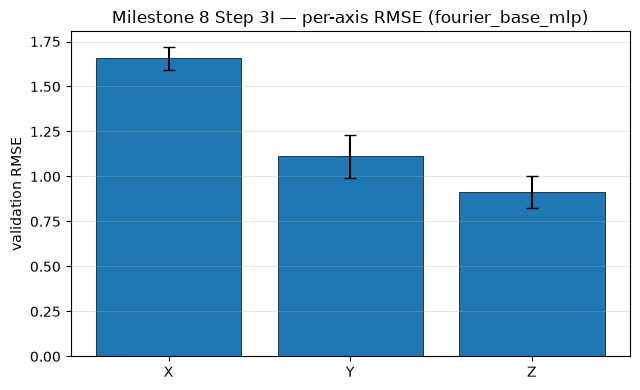

- M8 Step 3F: loaded 9 summary rows.

- M8 Step 3G: loaded 12 summary rows.

- M8 Step 3H: loaded 9 summary rows.

- Confirmatory triad loaded — report validation RMSE total **and** per-axis X/Y/Z.

- Single-view axis difficulty is not isotropic; do not hide structure in one scalar.

In [6]:
confirm_summary, confirm_runs = load_win3i_confirmatory_results(ROOT)
should_run = RUN_STUDY if RUN_STUDY is not None else (confirm_runs is None or confirm_runs.empty)
if should_run:
    rows = load_m8_catalog_rows(ROOT, data_mode=DATA_MODE)
    confirm_summary, confirm_runs, _ = run_win3i_confirmatory_study(
        rows,
        device=device,
        num_epochs=NUM_EPOCHS,
        early_stop_patience=EARLY_STOP,
        results_dir=results_dir,
        n_repeat=N_REPEAT,
        base_seed=BASE_SEED,
    )
write_win3i_manifest(ROOT, source_tables=sources, confirmatory_df=confirm_summary)
if confirm_summary is not None and not confirm_summary.empty:
    fig = plot_win3i_per_axis(confirm_summary)
    plt.show()
for line in summarize_win3i(sources, confirm_summary):
    display(Markdown(f"- {line}"))
